# Student Dropout Risk: Four-Model Comparison

**Course:** AIE1014 — Applied AI Project  
**Author:** Odunze Onyekachi (A00304592)  
**Date:** 2026-04-16  

This notebook is a clean, self-contained version of the model selection pipeline. It reproduces the full OULAD data loading and preprocessing, then trains four models at baseline and compares them head-to-head. The goal is a single readable document that makes the model selection decision traceable — no exploratory detours, no reused outputs from previous runs.

## Design Intent — Read Before Running

This comparison uses **two parallel data tracks**:

```
students (raw, 13 cols)
    |
    +--[Encode]-----------> X_enc  (28 features)  -->  Logistic Regression, Random Forest, XGBoost
    |
    +--[str + fillna]-----> X_raw  (12 features)  -->  CatBoost (native categorical handling)
```

**Why asymmetric?**  
- Models 1–3 receive label/ordinal/one-hot encoded features. Categorical structure is compressed into numbers.
- CatBoost receives raw string categoricals and handles them natively via its internal ordered target statistics. No information is discarded through encoding.

**This is intentional, not a bug.** The comparison answers: *does CatBoost's native handling recover the information lost by encoding, and is the gain worth changing the API's input contract?*

The final section (Section 12) frames the deployment tradeoff explicitly.

## Section 1: Imports

In [4]:
import warnings
import time
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
DATA_DIR     = '../data/raw/'
MODELS_DIR   = '../models/'

print('All imports OK')

c:\Users\odunz\OneDrive\Desktop\student-success-platform\ai-student-success\studRec\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK


## Section 2: Data Loading

We load from the raw CSVs directly to show the full pipeline. All five OULAD tables are loaded, then aggregated into a single per-student feature table.

### Dataset Selection Rationale

The OULAD dataset contains 7 files. We deliberately chose 4 and excluded 3.

**Files used:**

| File | Why included |
|------|--------------|
| `studentInfo.csv` | Core file — student demographics and `final_result` (our target variable) |
| `studentAssessment.csv` | Assessment submissions per student — source of `avg_score` and `completion_rate`, two of the strongest dropout predictors |
| `studentVle.csv` | Virtual Learning Environment click logs — source of `total_clicks`, a direct measure of student engagement |
| `assessments.csv` | Course-level assessment count — needed only to compute `completion_rate = assessments_submitted / total_assessments_in_course` |

**Files excluded and why:**

| File | Contains | Reason excluded |
|------|----------|-----------------|
| `studentRegistration.csv` | Registration date, **unregistration date** | **Data leakage** — `date_unregistration` is only populated when a student withdraws. Including it would mean predicting withdrawal using direct evidence of withdrawal, not behaviour leading up to it. |
| `courses.csv` | `module_presentation_length` | Course-level constant, not student-level behaviour. The module identity is already captured via `code_module`. |
| `vle.csv` | Activity type metadata (forum, quiz, resource, etc.) | Would require grouping clicks by activity type — adds pipeline complexity for marginal gain. `total_clicks` already captures overall engagement volume. |

> **Key point for the defence:** The exclusion of `studentRegistration.csv` is not an oversight — it is a deliberate choice to prevent data leakage. A model trained with `date_unregistration` would not be predicting risk; it would be reading the outcome directly.

In [5]:
# STEP 1: Load base student data
# studentInfo.csv is the core table with one row per student-module-presentation.
# Contains demographics (gender, region, age, education) plus final_result,
# which we later convert into our target variable (at_risk = 1 for Fail/Withdrawn).

# --- 2A: Student demographics ---
students = pd.read_csv(DATA_DIR + 'studentInfo.csv')
print(f'studentInfo: {students.shape}')  # expect (32593, 12)

studentInfo: (32593, 12)


In [6]:
# STEP 2: Aggregate assessment scores per student
# studentAssessment.csv has one row per submission. We join it with assessments.csv
# to get the module/presentation context, then aggregate per student:
#   avg_score        = mean score across all submitted assessments
#   assessment_count = number of assessments the student actually submitted
# Students who submitted nothing will have NaN here (handled in Section 4).

# --- 2B: Assessment scores → avg_score, assessment_count ---
raw_assessments = pd.read_csv(DATA_DIR + 'studentAssessment.csv')

# Merge to get code_module / code_presentation per submission
assessments_meta = pd.read_csv(DATA_DIR + 'assessments.csv')[['id_assessment', 'code_module', 'code_presentation']]
raw_assessments  = raw_assessments.merge(assessments_meta, on='id_assessment', how='left')

agg_assessments = (
    raw_assessments
    .groupby(['id_student', 'code_module', 'code_presentation'], as_index=False)
    .agg(avg_score=('score', 'mean'), assessment_count=('score', 'count'))
)

students = students.merge(agg_assessments, on=['id_student', 'code_module', 'code_presentation'], how='left')
print(f'After assessment merge: {students.shape}')

After assessment merge: (32593, 14)


In [7]:
# STEP 3: Aggregate VLE engagement per student
# studentVle.csv records every click on the Virtual Learning Environment (~10M rows).
# We sum all clicks per student to get total_clicks - a proxy for engagement.
# Students with no VLE activity will have NaN (handled in Section 4).

# --- 2C: VLE clicks → total_clicks  (~10M rows, takes a few seconds) ---
t0 = time.time()
vle = pd.read_csv(DATA_DIR + 'studentVle.csv')
print(f'studentVle loaded: {vle.shape}  ({time.time()-t0:.1f}s)')

agg_vle = (
    vle
    .groupby(['id_student', 'code_module', 'code_presentation'], as_index=False)
    .agg(total_clicks=('sum_click', 'sum'))
)

students = students.merge(agg_vle, on=['id_student', 'code_module', 'code_presentation'], how='left')
print(f'After VLE merge: {students.shape}')

studentVle loaded: (10655280, 6)  (4.3s)
After VLE merge: (32593, 15)


In [8]:
# STEP 4: Compute completion_rate
# completion_rate = assessments submitted / total assessments in the course (0.0-1.0)
# This normalised metric is better than raw count because different courses
# have different numbers of assessments. It directly measures course engagement.

# --- 2D: completion_rate = assessment_count / total_assessments_in_course ---
course_assessments = (
    pd.read_csv(DATA_DIR + 'assessments.csv')
    .groupby(['code_module', 'code_presentation'], as_index=False)
    .agg(total_assessments=('id_assessment', 'count'))
)

students = students.merge(course_assessments, on=['code_module', 'code_presentation'], how='left')
students['completion_rate'] = students['assessment_count'] / students['total_assessments']

print(f'After completion_rate: {students.shape}')
students.head(3)

After completion_rate: (32593, 17)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,assessment_count,total_clicks,total_assessments,completion_rate
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0,6,0.833333
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0,6,0.833333
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0,6,NaN


## Section 3: Exploratory Data Analysis (EDA)

We explore the data **before** cleaning or modelling. This is how we justify every decision made in the next section — what to fill, what to drop, whether resampling is needed, and which features are likely to matter.

> Note: `students` here is the raw merged DataFrame — missing values and imd_band formatting are not yet fixed.

In [9]:
# --- EDA A: Dataset Overview ---
print(f"Shape: {students.shape}")
print(f"Rows: {len(students):,}  |  Columns: {len(students.columns)}")
print()
print("Column names and dtypes:")
print(students.dtypes.to_string())
print()
print("Sample rows:")
students.head(5)

Shape: (32593, 17)
Rows: 32,593  |  Columns: 17

Column names and dtypes:
code_module              object
code_presentation        object
id_student                int64
gender                   object
region                   object
highest_education        object
imd_band                 object
age_band                 object
num_of_prev_attempts      int64
studied_credits           int64
disability               object
final_result             object
avg_score               float64
assessment_count        float64
total_clicks            float64
total_assessments         int64
completion_rate         float64

Sample rows:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,avg_score,assessment_count,total_clicks,total_assessments,completion_rate
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,82.0,5.0,934.0,6,0.833333
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,66.4,5.0,1435.0,6,0.833333
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,NaN,NaN,281.0,6,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,76.0,5.0,2158.0,6,0.833333
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,54.4,5.0,1034.0,6,0.833333


In [10]:
# --- EDA A: Descriptive statistics for numeric columns ---
students.describe().round(2)

,id_student,num_of_prev_attempts,studied_credits,avg_score,assessment_count,total_clicks,total_assessments,completion_rate
count,32593.00,32593.00,32593.00,25820.00,25843.00,29228.00,32593.00,25843.00
mean,706687.67,0.16,79.76,72.77,6.72,1355.04,9.94,0.68
std,549167.31,0.48,41.07,16.37,3.77,1733.55,2.93,0.30
min,3733.00,0.00,30.00,0.00,0.00,1.00,5.00,0.00
25%,508573.00,0.00,60.00,64.67,4.00,260.75,7.00,0.42
50%,590310.00,0.00,60.00,76.00,7.00,739.50,10.00,0.83
75%,644453.00,0.00,120.00,84.55,10.00,1770.00,13.00,0.92
max,2716795.00,6.00,655.00,100.00,14.00,24139.00,14.00,1.00


Columns with missing values:
                  Missing Count  Missing %
avg_score                  6773       20.8
completion_rate            6750       20.7
assessment_count           6750       20.7
total_clicks               3365       10.3
imd_band                   1111        3.4


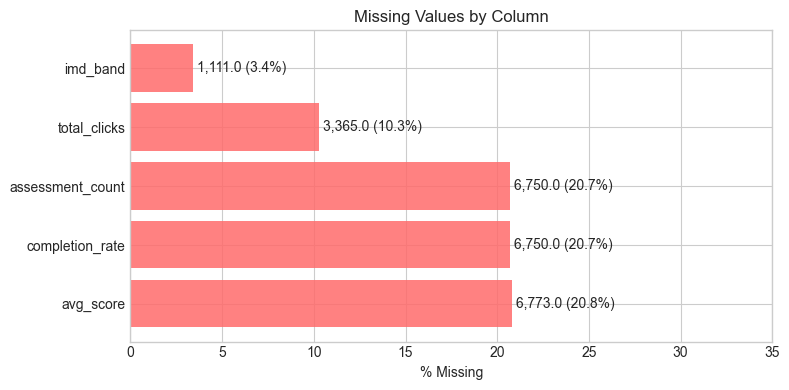


Interpretation:
  avg_score / completion_rate NaN  → student submitted no assessments → fill with 0
  total_clicks NaN               → student had no VLE activity → fill with 0
  imd_band NaN                   → deprivation band not recorded → fill with 'Unknown'


In [11]:
# --- EDA B: Missing Values ---
missing = students.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(students) * 100).round(1)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})
print("Columns with missing values:")
print(missing_df.to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_df.index, missing_df["Missing %"], color="#FF6B6B", alpha=0.85)
for bar, (_, row) in zip(bars, missing_df.iterrows()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{row["Missing Count"]:,} ({row["Missing %"]}%)',
            va="center", fontsize=10)
ax.set_xlabel("% Missing")
ax.set_title("Missing Values by Column")
ax.set_xlim(0, 35)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  avg_score / completion_rate NaN  → student submitted no assessments → fill with 0")
print("  total_clicks NaN               → student had no VLE activity → fill with 0")
print("  imd_band NaN                   → deprivation band not recorded → fill with 'Unknown'")

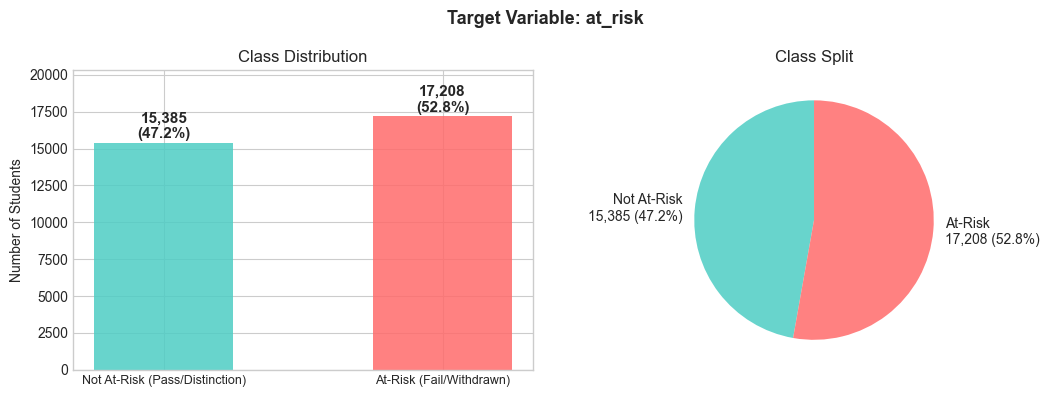

At-risk  : 17,208 students (52.8%)
Not at-risk: 15,385 students (47.2%)

Classes are balanced — no resampling (SMOTE/oversampling) needed.
Stratified train/test split will preserve this ratio in both sets.


In [12]:
# --- EDA C: Class Balance ---
target_col = students["final_result"].isin(["Fail", "Withdrawn"]).astype(int)
counts = target_col.value_counts().sort_index()
labels = ["Not At-Risk (Pass/Distinction)", "At-Risk (Fail/Withdrawn)"]
colors = ["#4ECDC4", "#FF6B6B"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, alpha=0.85, width=0.5)
for bar, count in zip(bars, counts.values):
    pct = count / len(target_col) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Number of Students")
axes[0].set_title("Class Distribution")
axes[0].set_ylim(0, max(counts.values) * 1.18)
axes[0].tick_params(axis="x", labelsize=9)

# Pie chart
axes[1].pie(counts.values, labels=[f"{l}\n{c:,} ({c/len(target_col)*100:.1f}%)"
            for l, c in zip(["Not At-Risk", "At-Risk"], counts.values)],
            colors=colors, autopct="", startangle=90,
            wedgeprops=dict(alpha=0.85))
axes[1].set_title("Class Split")

plt.suptitle("Target Variable: at_risk", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

at_risk_pct = counts[1] / len(target_col) * 100
print(f"At-risk  : {counts[1]:,} students ({at_risk_pct:.1f}%)")
print(f"Not at-risk: {counts[0]:,} students ({100-at_risk_pct:.1f}%)")
print()
print("Classes are balanced — no resampling (SMOTE/oversampling) needed.")
print("Stratified train/test split will preserve this ratio in both sets.")

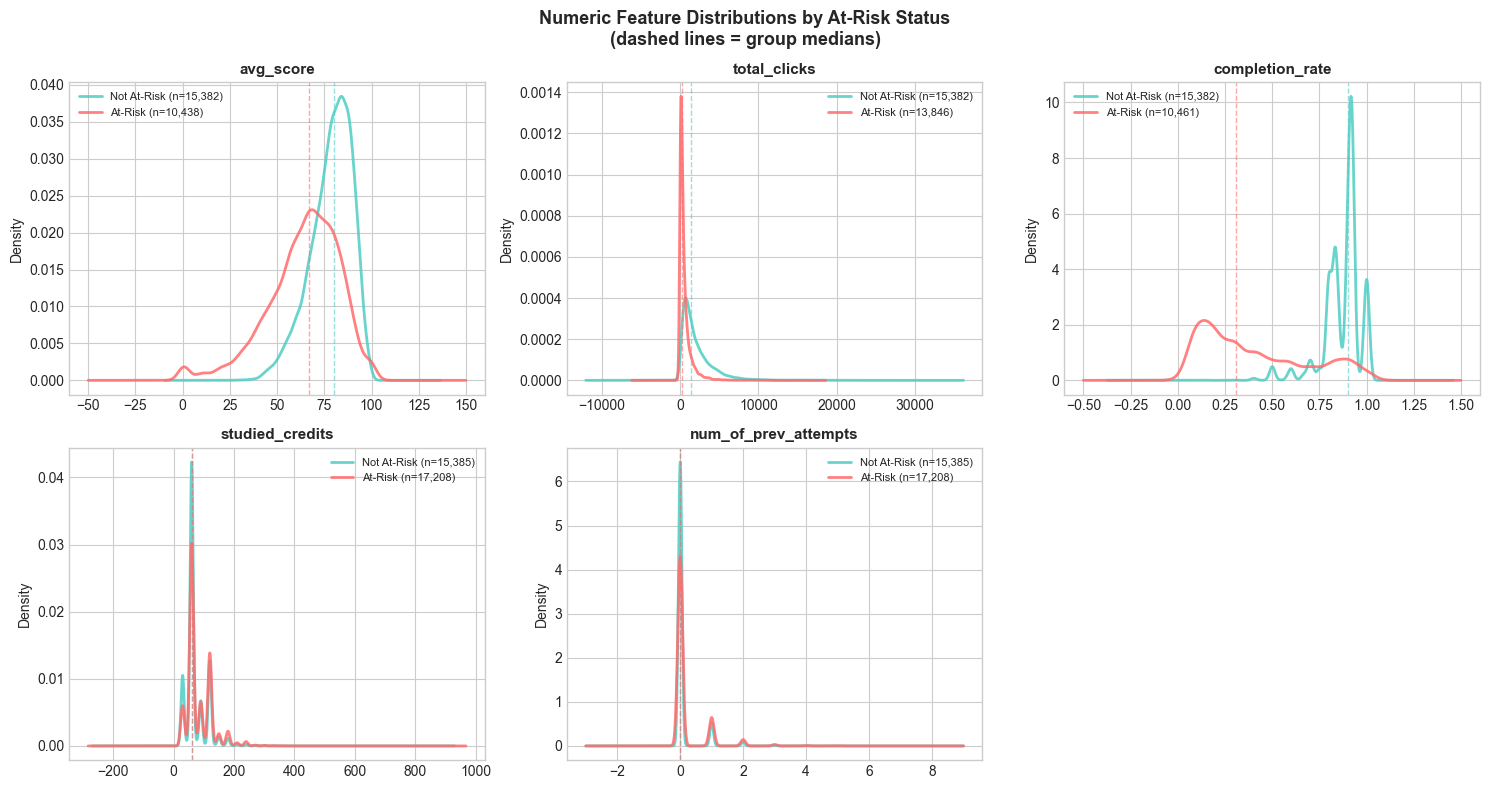

Median values by group:
                              Not At-Risk      At-Risk   Difference
-----------------------------------------------------------------
avg_score                           80.27        66.85       -13.43
total_clicks                      1425.00       280.50     -1144.50
completion_rate                      0.90         0.31        -0.59
studied_credits                     60.00        60.00        +0.00
num_of_prev_attempts                 0.00         0.00        +0.00


In [13]:
# --- EDA D: Numeric Feature Distributions ---
# Goal: visualise how each numeric feature separates at-risk vs not-at-risk students.
# A feature with clear separation between the two groups is a strong predictor.
# We use KDE (Kernel Density Estimate) plots — smoother than histograms,
# better for comparing distributions on the same axis.

# Use the raw students DataFrame before NaN filling so the distributions
# reflect actual submitted data (not the zero-filled version).
plot_df = students.copy()
plot_df["at_risk"] = plot_df["final_result"].isin(["Fail", "Withdrawn"]).astype(int)

numeric_features = ["avg_score", "total_clicks", "completion_rate",
                    "studied_credits", "num_of_prev_attempts"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors = {0: "#4ECDC4", 1: "#FF6B6B"}  # teal = not at-risk, red = at-risk
labels = {0: "Not At-Risk", 1: "At-Risk"}

for i, feat in enumerate(numeric_features):
    ax = axes[i]
    # Drop NaNs for this feature only — we want real submitted values
    subset = plot_df[[feat, "at_risk"]].dropna()
    for risk_val in [0, 1]:
        group = subset[subset["at_risk"] == risk_val][feat]
        group.plot.kde(ax=ax, color=colors[risk_val],
                       label=f"{labels[risk_val]} (n={len(group):,})",
                       linewidth=2, alpha=0.85)
        ax.axvline(group.median(), color=colors[risk_val],
                   linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.set_ylabel("Density")

# Hide the unused 6th subplot
axes[-1].set_visible(False)

plt.suptitle("Numeric Feature Distributions by At-Risk Status\n"
             "(dashed lines = group medians)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Print median values per group for each feature — numbers behind the plot
print("Median values by group:")
print(f"{"": <25} {"Not At-Risk":>15} {"At-Risk":>12} {"Difference":>12}")
print("-" * 65)
for feat in numeric_features:
    subset = plot_df[[feat, "at_risk"]].dropna()
    med_0 = subset[subset["at_risk"] == 0][feat].median()
    med_1 = subset[subset["at_risk"] == 1][feat].median()
    diff  = med_1 - med_0
    print(f"{feat: <25} {med_0:>15.2f} {med_1:>12.2f} {diff:>+12.2f}")

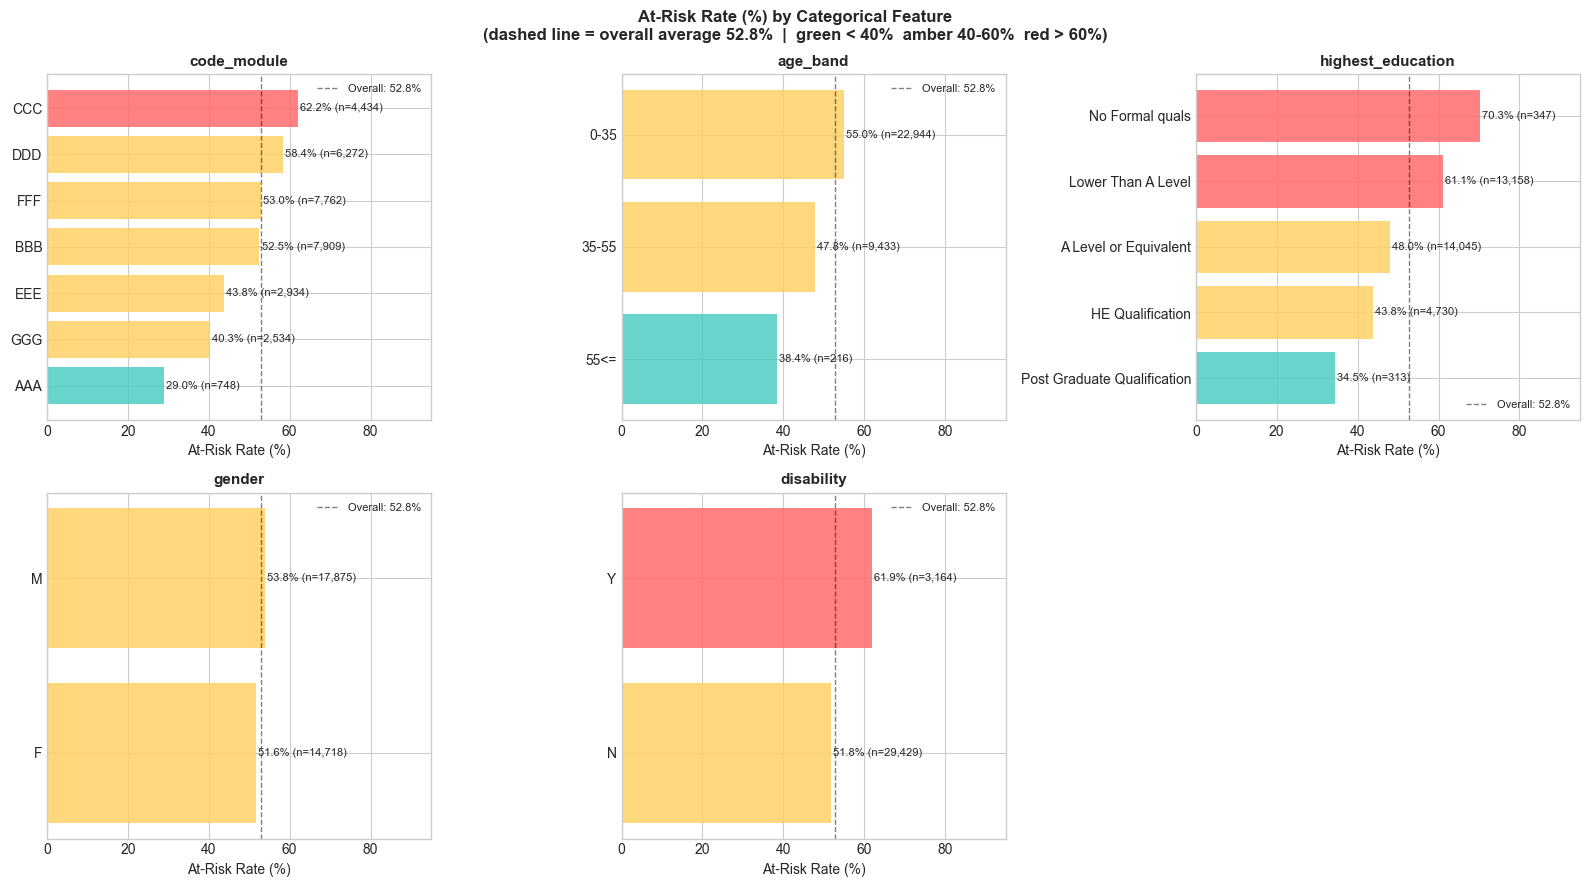


Region — At-Risk Rate (sorted):
                      Students  At-Risk %
region                                   
North Western Region      2906       59.8
London Region             3216       57.6
West Midlands Region      2582       56.7
Yorkshire Region          2006       55.1
Wales                     2086       54.8
East Midlands Region      2365       54.3
Scotland                  3446       51.0
East Anglian Region       3340       51.0
South West Region         2436       50.2
North Region              1823       49.5
South East Region         2111       48.5
South Region              3092       47.6
Ireland                   1184       45.1

imd_band (deprivation decile) — At-Risk Rate (sorted by band):
          Students  At-Risk %
imd_band                     
0-10%         3311       64.8
20-30%        3654       59.3
30-40%        3539       53.1
40-50%        3256       53.4
50-60%        3124       51.2
60-70%        2905       48.1
70-80%        2879       48.5
80-

In [14]:
# --- EDA E: Categorical Feature Distributions ---
# Goal: see how dropout risk varies across categorical groups.
# Instead of raw counts, we plot AT-RISK RATE (%) per category —
# this shows which groups have higher dropout probability regardless of group size.
#
# code_module, age_band, highest_education, gender, disability → bar charts
# region and imd_band → sorted tables (too many categories for readable bar charts)

plot_df = students.copy()
plot_df["at_risk"] = plot_df["final_result"].isin(["Fail", "Withdrawn"]).astype(int)

# Features to plot as bar charts
cat_features = ["code_module", "age_band", "highest_education", "gender", "disability"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ax = axes[i]

    # Compute at-risk rate and total count per category
    group = plot_df.groupby(feat)["at_risk"].agg(["mean", "count"]).reset_index()
    group.columns = [feat, "at_risk_rate", "count"]
    group["at_risk_pct"] = group["at_risk_rate"] * 100
    group = group.sort_values("at_risk_pct", ascending=True)  # ascending for readability

    # Colour bars by risk level: green < 40%, amber 40-60%, red > 60%
    bar_colors = ["#FF6B6B" if p > 60 else "#FFD166" if p > 40 else "#4ECDC4"
                  for p in group["at_risk_pct"]]

    bars = ax.barh(group[feat].astype(str), group["at_risk_pct"],
                   color=bar_colors, alpha=0.85)

    # Annotate bars with % and sample count
    for bar, (_, row) in zip(bars, group.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{row["at_risk_pct"]:.1f}% (n={row["count"]:,})',
                va="center", fontsize=8)

    # Reference line at overall at-risk rate
    overall_rate = plot_df["at_risk"].mean() * 100
    ax.axvline(overall_rate, color="black", linestyle="--",
               linewidth=1, alpha=0.5, label=f"Overall: {overall_rate:.1f}%")

    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("At-Risk Rate (%)")
    ax.set_xlim(0, 95)
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].set_visible(False)

plt.suptitle("At-Risk Rate (%) by Categorical Feature\n"
             "(dashed line = overall average 52.8%  |  "
             "green < 40%  amber 40-60%  red > 60%)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Region: top 5 highest and lowest risk regions (table) ---
print("\nRegion — At-Risk Rate (sorted):")
region_risk = (
    plot_df.groupby("region")["at_risk"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "At-Risk Rate", "count": "Students"})
    .assign(**{"At-Risk %": lambda x: (x["At-Risk Rate"] * 100).round(1)})
    .sort_values("At-Risk %", ascending=False)
    [["Students", "At-Risk %"]]
)
print(region_risk.to_string())

# --- imd_band: deprivation decile vs at-risk rate ---
print("\nimd_band (deprivation decile) — At-Risk Rate (sorted by band):")
imd_order = ["0-10%","10-20%","20-30%","30-40%","40-50%",
             "50-60%","60-70%","70-80%","80-90%","90-100%","Unknown"]
imd_risk = (
    plot_df.groupby("imd_band")["at_risk"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "At-Risk Rate", "count": "Students"})
    .assign(**{"At-Risk %": lambda x: (x["At-Risk Rate"] * 100).round(1)})
    .reindex([b for b in imd_order if b in plot_df["imd_band"].values])
    [["Students", "At-Risk %"]]
)
print(imd_risk.to_string())

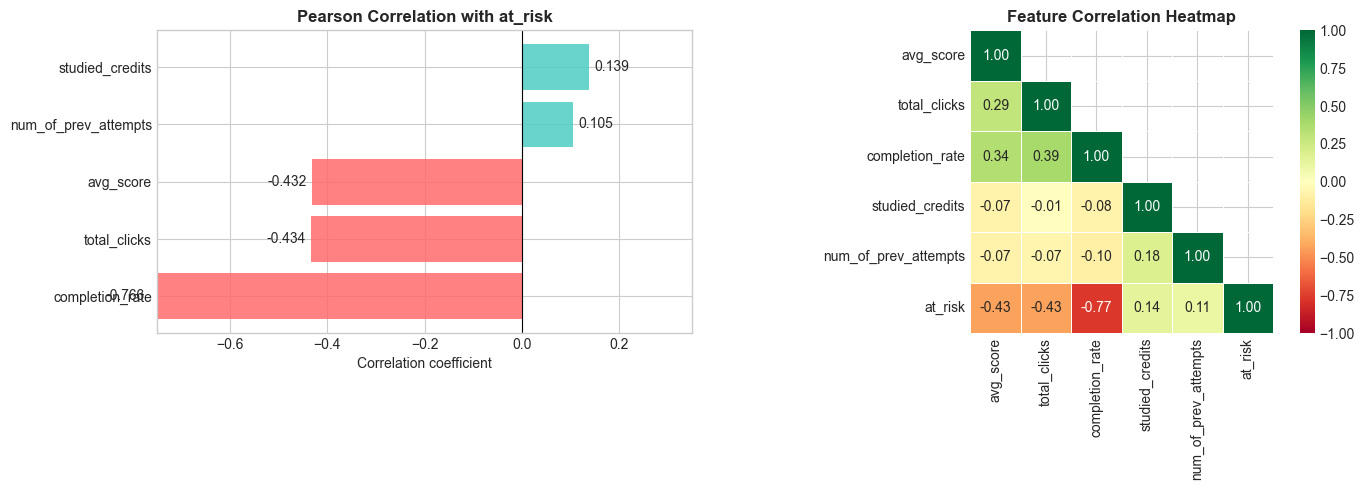

Correlation with at_risk (strongest first):
completion_rate        -0.765969
total_clicks           -0.433879
avg_score              -0.432316
num_of_prev_attempts    0.105460
studied_credits         0.138630

Multicollinearity check:
  avg_score vs completion_rate : 0.344
  avg_score vs total_clicks    : 0.293
  completion_rate vs total_clicks: 0.394

Note: moderate inter-feature correlation is acceptable for tree-based models.
Logistic Regression may be slightly affected but max_iter=1000 handles it.


In [15]:
# --- EDA F: Correlation with Target ---
# Two things we check here:
#   1. How strongly does each numeric feature correlate with at_risk?
#      This tells us which features are individually predictive.
#   2. Do any numeric features correlate strongly with EACH OTHER?
#      High inter-feature correlation (multicollinearity) can make
#      coefficient-based models like Logistic Regression unstable.
#      Tree-based models (RF, XGBoost, CatBoost) handle it fine.

corr_df = students.copy()
corr_df["at_risk"] = corr_df["final_result"].isin(["Fail", "Withdrawn"]).astype(int)

numeric_cols = ["avg_score", "total_clicks", "completion_rate",
               "studied_credits", "num_of_prev_attempts", "at_risk"]

# Pearson correlation matrix on numeric columns only
corr_matrix = corr_df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Feature correlation with at_risk (horizontal bar chart) ---
target_corr = (
    corr_matrix["at_risk"]
    .drop("at_risk")           # remove self-correlation
    .sort_values()
)
colors = ["#FF6B6B" if v < 0 else "#4ECDC4" for v in target_corr.values]
bars = axes[0].barh(target_corr.index, target_corr.values, color=colors, alpha=0.85)
for bar, val in zip(bars, target_corr.values):
    axes[0].text(
        val - 0.01 if val < 0 else val + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}", va="center",
        ha="right" if val < 0 else "left", fontsize=10
    )
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Pearson Correlation with at_risk", fontweight="bold")
axes[0].set_xlabel("Correlation coefficient")
axes[0].set_xlim(-0.75, 0.35)

# --- Plot 2: Full correlation heatmap (multicollinearity check) ---
mask = [[i <= j for j in range(len(numeric_cols))] for i in range(len(numeric_cols))]
import numpy as np
mask_arr = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, vmin=-1, vmax=1,
    mask=mask_arr,          # show lower triangle only — upper is a mirror
    square=True, linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("Feature Correlation Heatmap", fontweight="bold")

plt.tight_layout()
plt.show()

# Print key correlation values clearly
print("Correlation with at_risk (strongest first):")
print(target_corr.sort_values().to_string())
print()
print("Multicollinearity check:")
print("  avg_score vs completion_rate :",
      round(corr_matrix.loc["avg_score", "completion_rate"], 3))
print("  avg_score vs total_clicks    :",
      round(corr_matrix.loc["avg_score", "total_clicks"], 3))
print("  completion_rate vs total_clicks:",
      round(corr_matrix.loc["completion_rate", "total_clicks"], 3))
print()
print("Note: moderate inter-feature correlation is acceptable for tree-based models.")
print("Logistic Regression may be slightly affected but max_iter=1000 handles it.")

### EDA Summary — Key Findings

Everything the EDA revealed directly justifies a decision made later in the pipeline:

| Finding | Decision it justifies |
|---------|----------------------|
| 20.8% of students have no `avg_score` or `completion_rate` — they never submitted anything | Fill NaN with **0**, not the mean. A mean fill would assign a score they never earned. |
| 10.3% have no `total_clicks` — zero VLE activity | Fill NaN with **0** — they genuinely did not engage. |
| 3.4% missing `imd_band` | Fill with **"Unknown"** — preserves them as a distinct group for CatBoost. |
| Classes are 52.8% / 47.2% — near-balanced | **No SMOTE or oversampling needed.** Accuracy is a fair metric. |
| `completion_rate` correlation with `at_risk` = **-0.766** | Strongest single predictor. Expect it as the top SHAP feature. |
| `studied_credits` and `num_of_prev_attempts` show zero median difference | Low predictive value — the model will assign them low importance. |
| `imd_band` 0-10% → 64.8% dropout vs 90-100% → 42.5% | Socioeconomic band is a meaningful feature — justifies keeping it. |
| Inter-feature correlations are moderate (max 0.39) | No serious multicollinearity. Tree-based models are unaffected. |
| Categorical features show meaningful at-risk rate differences across groups | Justifies **CatBoost with native categorical handling** over encoding. |

## Section 3: Missing Values, imd_band Fix, Target Engineering

In [16]:
# STEP 5: Handle missing values
# NaN in avg_score / completion_rate -> student submitted nothing -> fill with 0
# NaN in total_clicks                -> no VLE activity at all   -> fill with 0
# NaN in imd_band                    -> deprivation band unknown  -> "Unknown"
#
# We do NOT fill with the column mean because NaN here has a specific meaning:
# the student was absent, not just unlucky. Mean imputation would distort that signal.
# imd_band gets "Unknown" so CatBoost treats it as its own group, not a missing value.

# --- 3A: Missing values ---
students['avg_score']    = students['avg_score'].fillna(0)
students['total_clicks'] = students['total_clicks'].fillna(0)
students['completion_rate'] = students['completion_rate'].fillna(0)

# imd_band: add '%' to values missing it (e.g. '10-20' → '10-20%'), then fill NaN → 'Unknown'
students['imd_band'] = (
    students['imd_band']
    .apply(lambda x: x + '%' if pd.notna(x) and isinstance(x, str) and not x.endswith('%') else x)
    .fillna('Unknown')
)

# Helper flag (used only to derive completion_rate, dropped below)
students['has_assessments'] = (students['assessment_count'] > 0).fillna(False)

print('Missing values after fill:')
print(students[['avg_score','total_clicks','completion_rate','imd_band']].isnull().sum())

Missing values after fill:
avg_score          0
total_clicks       0
completion_rate    0
imd_band           0
dtype: int64


In [17]:
# STEP 6: Create target variable and drop irrelevant columns
# at_risk = 1 if student Failed or Withdrew, 0 if they Passed or got Distinction.
#
# Columns dropped and why:
#   id_student        -> row identifier, no predictive signal
#   code_presentation -> semester ID, not a student behaviour feature
#   final_result      -> this IS the target - keeping it would be data leakage
#   assessment_count  -> redundant once we have completion_rate
#   has_assessments   -> redundant (completion_rate=0 already captures this)
#   total_assessments -> course metadata, not a student-level feature

# --- 3B: Target + column drops ---
students['at_risk'] = students['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

print('Target distribution:')
print(students['at_risk'].value_counts())
print(f"At-risk rate: {students['at_risk'].mean()*100:.1f}%")

DROP_COLS = ['id_student', 'code_presentation', 'final_result',
             'assessment_count', 'has_assessments', 'total_assessments']
students.drop(columns=DROP_COLS, inplace=True)

print(f'\nFinal columns ({len(students.columns)}):')
print(list(students.columns))
# expect 13: code_module gender region highest_education imd_band age_band
#            num_of_prev_attempts studied_credits disability avg_score
#            total_clicks completion_rate at_risk

Target distribution:
at_risk
1    17208
0    15385
Name: count, dtype: int64
At-risk rate: 52.8%

Final columns (13):
['code_module', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'avg_score', 'total_clicks', 'completion_rate', 'at_risk']


## Section 4: Two-Track Feature Preparation

This is where the pipeline forks. **Never mix variables across tracks** — `X_enc*` variables are for LR/RF/XGBoost, `X_raw*` variables are for CatBoost.

In [18]:
# STEP 7: Train/Test Split — done FIRST before any encoding
#
# Industry standard: split the raw data before fitting any transformations.
# Encoding must only "see" the training set — applying it to the full dataset
# before splitting could leak test set information into the training process.
#
# In our case the ordinal maps are hardcoded (no data leakage in practice),
# but we follow the correct structure regardless — it is the right pattern
# and removes any ambiguity during review or defence.
#
# stratify=y ensures the 52.8/47.2 at-risk ratio is preserved in both sets.

# Separate features from target
y = students["at_risk"]
X = students.drop("at_risk", axis=1)   # 12 raw columns

# Split raw DataFrame — same seed used for both tracks below
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {len(y_train):,} rows  |  At-risk: {y_train.mean()*100:.1f}%")
print(f"Test  : {len(y_test):,} rows  |  At-risk: {y_test.mean()*100:.1f}%")

Train : 26,074 rows  |  At-risk: 52.8%
Test  : 6,519 rows  |  At-risk: 52.8%


In [19]:
# STEP 8A: Build the ENCODED feature set (Logistic Regression, Random Forest, XGBoost)
#
# Encoding is applied to the TRAINING set only, then the same transformation
# is applied to the test set. Nothing is "fitted" from the test set.
#
# Encoding strategies:
#   Binary encoding  : 2-category cols (gender, disability) -> 0 or 1
#   Ordinal encoding : naturally ordered cols (age_band, highest_education,
#                      imd_band) -> integers preserving the natural order
#   One-hot encoding : unordered multi-category cols (code_module, region)
#                      -> one binary column per category
#                      drop_first=True avoids the dummy variable trap
#
# For OHE: we apply get_dummies to both train and test separately,
# then reindex the test set to match the train column structure.
# fill_value=0 handles any category present in test but not train (rare here
# since all 7 modules and 13 regions appear in both sets).

# Ordinal maps — defined once, applied to both train and test identically
age_map = {"0-35": 0, "35-55": 1, "55<=": 2}
edu_map = {
    "No Formal quals": 0,
    "Lower Than A Level": 1,
    "A Level or Equivalent": 2,
    "HE Qualification": 3,
    "Post Graduate Qualification": 4
}
imd_map = {
    "0-10%": 0,  "10-20%": 1, "20-30%": 2, "30-40%": 3, "40-50%": 4,
    "50-60%": 5, "60-70%": 6, "70-80%": 7, "80-90%": 8, "90-100%": 9,
    "Unknown": -1
}

def apply_encoding(df):
    """Apply all encoding steps to a DataFrame. Pure function — no fitting."""
    df = df.copy()
    # Binary
    df["gender"]     = df["gender"].map({"M": 1, "F": 0})
    df["disability"] = df["disability"].map({"Y": 1, "N": 0})
    # Ordinal
    df["age_band"]          = df["age_band"].map(age_map)
    df["highest_education"] = df["highest_education"].map(edu_map)
    df["imd_band"]          = df["imd_band"].map(imd_map)
    # One-hot: code_module and region
    df = pd.get_dummies(df, columns=["code_module"], prefix="module", drop_first=True)
    df = pd.get_dummies(df, columns=["region"],      prefix="region",  drop_first=True)
    # Cast bool columns to int (newer pandas get_dummies returns bool)
    bool_cols = df.select_dtypes(include="bool").columns
    df[bool_cols] = df[bool_cols].astype(int)
    return df

# Encode train set — this defines the reference column structure
X_enc_train = apply_encoding(X_train_base)

# Encode test set using the same maps, then align columns to train
# reindex ensures test has exactly the same columns in the same order as train
X_enc_test = apply_encoding(X_test_base).reindex(
    columns=X_enc_train.columns, fill_value=0
)

# StandardScaler: fit on train only, transform both — only used for Logistic Regression
scaler = StandardScaler()
X_lr_train = scaler.fit_transform(X_enc_train)   # learns mean/std from train
X_lr_test  = scaler.transform(X_enc_test)         # applies train stats to test

print(f"Encoded train : {X_enc_train.shape}  |  Encoded test : {X_enc_test.shape}")
print(f"Features      : {X_enc_train.shape[1]}")
print(f"Scaler fitted on train only — test stats never seen during fit.")

Encoded train : (26074, 28)  |  Encoded test : (6519, 28)
Features      : 28
Scaler fitted on train only — test stats never seen during fit.


In [20]:
# STEP 8B: Build the RAW feature set (CatBoost only)
#
# No encoding needed — CatBoost handles categorical features natively.
# We just convert categorical columns to strings and fill any NaN.
#
# We build the raw track from the already-split base DataFrames (X_train_base,
# X_test_base) so both tracks originate from the same split — same row indices,
# same labels. The assert below confirms this.

cat_cols = ["code_module", "gender", "region", "highest_education",
            "imd_band", "age_band", "disability"]

def prepare_raw(df):
    """Convert categorical columns to strings for CatBoost native handling."""
    df = df.copy()
    for col in cat_cols:
        df[col] = df[col].fillna("Unknown").astype(str)
    return df

X_raw_train = prepare_raw(X_train_base)
X_raw_test  = prepare_raw(X_test_base)

# y_raw_train and y_raw_test are the same as y_train / y_test
# (same split, same indices) — aliased for clarity when used with CatBoost
y_raw_train = y_train
y_raw_test  = y_test

# cat_feature_indices: column positions CatBoost needs for its native handler
# Must be computed AFTER column order is finalised
cat_feature_indices = [X_raw_train.columns.get_loc(col) for col in cat_cols]

# Safety check: both tracks must have identical test labels
import numpy as np
assert (y_test.values == y_raw_test.values).all(), "Test labels must be identical!"

print(f"Raw train : {X_raw_train.shape}  |  Raw test : {X_raw_test.shape}")
print(f"Cat feature indices: {cat_feature_indices}")
print(f"Assert passed — both tracks have identical test labels.")

Raw train : (26074, 12)  |  Raw test : (6519, 12)
Cat feature indices: [0, 1, 2, 3, 4, 5, 8]
Assert passed — both tracks have identical test labels.


## Section 5: Data Ready — Handoff Checkpoint

---
**STOP HERE** if you only need the preprocessing pipeline. Everything above this point is ETL + feature engineering. Everything below is model training and evaluation.

---

In [21]:
print('=' * 60)
print('PRE-TRAINING SUMMARY')
print('=' * 60)
print(f'Total samples        : {len(y):,}')
print(f'Train / Test split   : {len(y_train):,} / {len(y_test):,}')
print(f'At-risk rate (train) : {y_train.mean()*100:.1f}%')
print(f'At-risk rate (test)  : {y_test.mean()*100:.1f}%')
print()
print('Encoded track  →  Logistic Regression, Random Forest, XGBoost')
print(f'  Features : {X_enc_train.shape[1]}  (5 numeric + ordinal/binary/OHE categoricals)')
print()
print('Raw track  →  CatBoost')
print(f'  Features : {X_raw_train.shape[1]}  (5 numeric + 7 raw string categoricals)')
print(f'  Cat cols : {cat_cols}')

PRE-TRAINING SUMMARY
Total samples        : 32,593
Train / Test split   : 26,074 / 6,519
At-risk rate (train) : 52.8%
At-risk rate (test)  : 52.8%

Encoded track  →  Logistic Regression, Random Forest, XGBoost
  Features : 28  (5 numeric + ordinal/binary/OHE categoricals)

Raw track  →  CatBoost
  Features : 12  (5 numeric + 7 raw string categoricals)
  Cat cols : ['code_module', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']


## Section 6: Training Four Models

| Model               | Input data    | Scaled | Categorical handling |
|---------------------|---------------|--------|----------------------|
| Logistic Regression | X_enc (28)    | Yes    | Pre-encoded (ordinal/OHE) |
| Random Forest       | X_enc (28)    | No     | Pre-encoded (ordinal/OHE) |
| XGBoost             | X_enc (28)    | No     | Pre-encoded (ordinal/OHE) |
| CatBoost            | X_raw (12)    | No     | Native (raw strings)  |

In [22]:
# MODEL 1: Logistic Regression
# A linear model that serves as our baseline. Simple, interpretable, fast.
# Uses scaled features (X_lr_train) because gradient descent converges faster
# when all features are on the same scale.
# max_iter=1000 ensures convergence despite the moderate inter-feature correlation
# we observed in EDA (default 100 iterations may not converge).

# --- 6A: Logistic Regression ---
print('Training Logistic Regression...')
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_lr_train, y_train)
lr_time = time.time() - t0
print(f'Done in {lr_time:.2f}s')

Training Logistic Regression...
Done in 0.04s


In [23]:
# MODEL 2: Random Forest
# An ensemble of decision trees trained on random feature subsets (bagging).
# Does not require feature scaling - tree splits are scale-invariant.
# n_estimators=100: 100 trees is a good baseline - enough to stabilise predictions
# without excessive training time.
# n_jobs=-1: use all CPU cores for parallel tree training.

# --- 6B: Random Forest ---
print('Training Random Forest...')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_enc_train, y_train)
rf_time = time.time() - t0
print(f'Done in {rf_time:.2f}s')

Training Random Forest...
Done in 0.39s


In [24]:
# MODEL 3: XGBoost (Extreme Gradient Boosting)
# Builds trees sequentially, each correcting the errors of the previous one.
# Does not need scaling. No use_label_encoder parameter - removed in XGBoost v2.0.
# eval_metric="logloss": log loss is appropriate for binary classification
# as it penalises confident wrong predictions heavily.

# --- 6C: XGBoost (no use_label_encoder — removed in v2.0) ---
print('Training XGBoost...')
t0 = time.time()
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=RANDOM_STATE
)
xgb.fit(X_enc_train, y_train)
xgb_time = time.time() - t0
print(f'Done in {xgb_time:.2f}s')

Training XGBoost...
Done in 1.08s


In [25]:
# MODEL 4: CatBoost (Categorical Boosting)
# Gradient boosting designed specifically for datasets with categorical features.
# Uses the RAW track (X_raw_train) with string categoricals - NOT the encoded set.
# cat_features=cat_feature_indices tells CatBoost which column positions are
# categorical so it applies its native ordered target statistics instead of
# treating them as numeric values.
# eval_metric="F1": F1 is the tuning objective - balances precision and recall,
# which is appropriate for a dropout risk context where both matter.
# verbose=0: suppresses per-iteration training output.

# --- 6D: CatBoost (raw track, native categorical handling) ---
print('Training CatBoost (native categorical handling)...')
t0 = time.time()
cb = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_feature_indices,
    eval_metric='F1',
    random_seed=RANDOM_STATE,
    verbose=0
)
cb.fit(X_raw_train, y_raw_train)
cb_time = time.time() - t0
print(f'Done in {cb_time:.2f}s')
print('All four models trained.')

Training CatBoost (native categorical handling)...
Done in 46.52s
All four models trained.


## Section 7: Evaluation

In [26]:
# EVALUATION: Compute all metrics for each model on the held-out test set
#
# model_specs ties each model to the correct test data:
#   LR     -> X_lr_test  (scaled encoded)    -> y_test
#   RF     -> X_enc_test (unscaled encoded)  -> y_test
#   XGBoost-> X_enc_test (unscaled encoded)  -> y_test
#   CatBoost-> X_raw_test (raw strings)      -> y_raw_test
#
# Note: y_test and y_raw_test contain identical values (confirmed by assert above)
# but we use the semantically correct variable for each model.
#
# Metrics explained:
#   Accuracy  : % of all predictions correct (fair here - classes are balanced)
#   Precision : of students flagged at-risk, how many truly are (avoid false alarms)
#   Recall    : of truly at-risk students, how many we caught (avoid missing them)
#   F1        : harmonic mean of precision and recall
#   AUC-ROC   : discrimination ability across ALL thresholds (primary metric)

# --- 7A: Collect metrics ---
# CatBoost uses X_raw_test / y_raw_test — same label values as y_test (asserted above)
# but semantically correct to keep track variables together.

model_specs = [
    ('Logistic Regression', lr,  X_lr_test,  y_test,     lr_time,  'Encoded', X_lr_test.shape[1]),
    ('Random Forest',       rf,  X_enc_test, y_test,     rf_time,  'Encoded', X_enc_test.shape[1]),
    ('XGBoost',            xgb,  X_enc_test, y_test,     xgb_time, 'Encoded', X_enc_test.shape[1]),
    ('CatBoost',            cb,  X_raw_test, y_raw_test, cb_time,  'Raw',     X_raw_test.shape[1]),
]

rows = []
for name, model, X_t, y_t, train_sec, track, n_feat in model_specs:
    y_pred  = model.predict(X_t)
    y_proba = model.predict_proba(X_t)[:, 1]
    rows.append({
        'Model':          name,
        'Track':          track,
        'Features':       n_feat,
        'Accuracy':       accuracy_score(y_t, y_pred),
        'Precision':      precision_score(y_t, y_pred),
        'Recall':         recall_score(y_t, y_pred),
        'F1':             f1_score(y_t, y_pred),
        'AUC-ROC':        roc_auc_score(y_t, y_proba),
        'Train Time (s)': round(train_sec, 2),
    })

results_df = (
    pd.DataFrame(rows)
    .set_index('Model')
    .sort_values('AUC-ROC', ascending=False)
)

print('Metrics collected.')

Metrics collected.


In [27]:
# Display the results as a styled pandas table:
#   Green cell = best value for that metric across all models
#   Red cell   = worst value for that metric
# Sorted by AUC-ROC descending (our primary selection criterion).
# "Track" and "Features" columns make the asymmetry visible at a glance.

# --- 7B: Styled comparison table ---
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']

styled = (
    results_df
    .style
    .highlight_max(subset=metric_cols, color='#c6efce')
    .highlight_min(subset=metric_cols, color='#ffc7ce')
    .format({col: '{:.4f}' for col in metric_cols})
    .format({'Train Time (s)': '{:.2f}'})
    .set_caption('Model Comparison — sorted by AUC-ROC descending. Green = best, Red = worst per metric.')
)
styled

,Track,Features,Accuracy,Precision,Recall,F1,AUC-ROC,Train Time (s)
Model,,,,,,,,
CatBoost,Raw,12,0.928670,0.961550,0.900930,0.930253,0.978027,46.52
XGBoost,Encoded,28,0.925602,0.957882,0.898605,0.927297,0.977993,1.08
Random Forest,Encoded,28,0.924835,0.958101,0.896862,0.926471,0.974906,0.39
Logistic Regression,Encoded,28,0.921614,0.959837,0.888727,0.922914,0.973488,0.04


In [28]:
# --- 7C: Store probabilities for plots ---
proba_store = {}
for name, model, X_t, y_t, _, track, _ in model_specs:
    proba_store[name] = {
        'y_true':  y_t,
        'y_proba': model.predict_proba(X_t)[:, 1],
        'track':   track,
        'y_pred':  model.predict(X_t),
    }

## Section 8: Visualizations

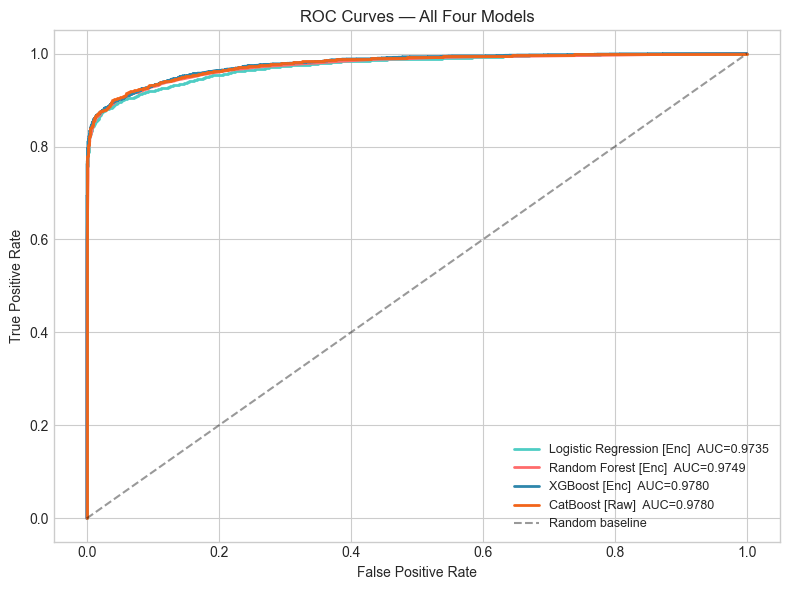

In [29]:
# ROC CURVE: plots True Positive Rate vs False Positive Rate at every threshold.
# The area under the curve (AUC) summarises overall discrimination ability.
# AUC = 1.0 is perfect, AUC = 0.5 is random guessing (the dashed diagonal).
# [Enc] / [Raw] labels in the legend make the two-track design explicit.

# --- 8A: ROC Curves ---
MODEL_COLORS = {
    'Logistic Regression': '#4ECDC4',
    'Random Forest':       '#FF6B6B',
    'XGBoost':             '#2E86AB',
    'CatBoost':            '#F26419',
}

fig, ax = plt.subplots(figsize=(8, 6))

for name, data in proba_store.items():
    fpr, tpr, _ = roc_curve(data['y_true'], data['y_proba'])
    auc = roc_auc_score(data['y_true'], data['y_proba'])
    tag = ' [Raw]' if data['track'] == 'Raw' else ' [Enc]'
    ax.plot(fpr, tpr, label=f"{name}{tag}  AUC={auc:.4f}",
            color=MODEL_COLORS[name], lw=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Four Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

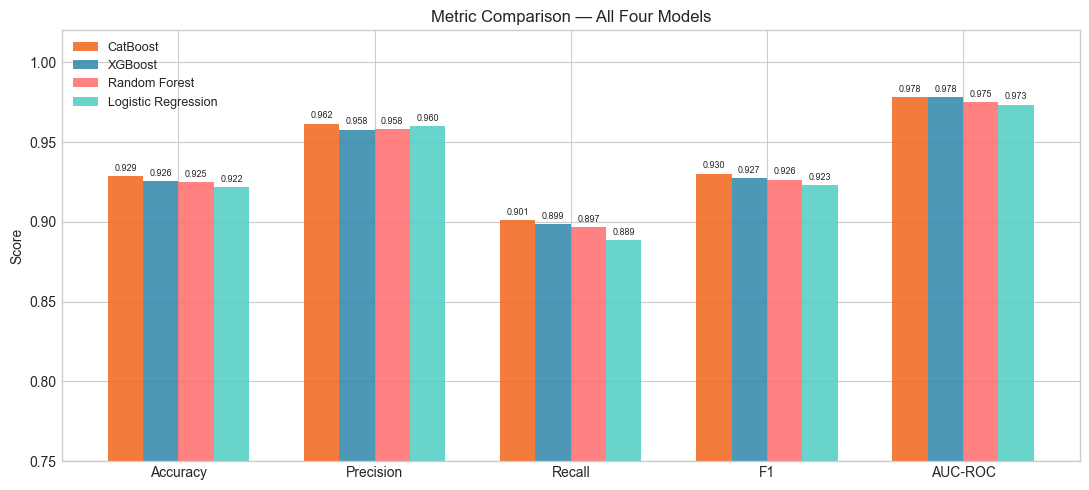

In [30]:
# BAR CHART: side-by-side comparison of all 5 metrics across all 4 models.
# Complements the ROC curves by showing absolute metric values, not curves.
# y-axis starts at 0.75 to magnify the differences between models.

# --- 8B: Grouped bar chart (5 metrics × 4 models) ---
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
plot_df = results_df[metric_cols]

x    = np.arange(len(metric_cols))
w    = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

fig, ax = plt.subplots(figsize=(11, 5))

for i, (name, row) in enumerate(plot_df.iterrows()):
    bars = ax.bar(x + offsets[i]*w, row.values, width=w,
                  label=name, color=MODEL_COLORS[name], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=6.5)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Score')
ax.set_title('Metric Comparison — All Four Models')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

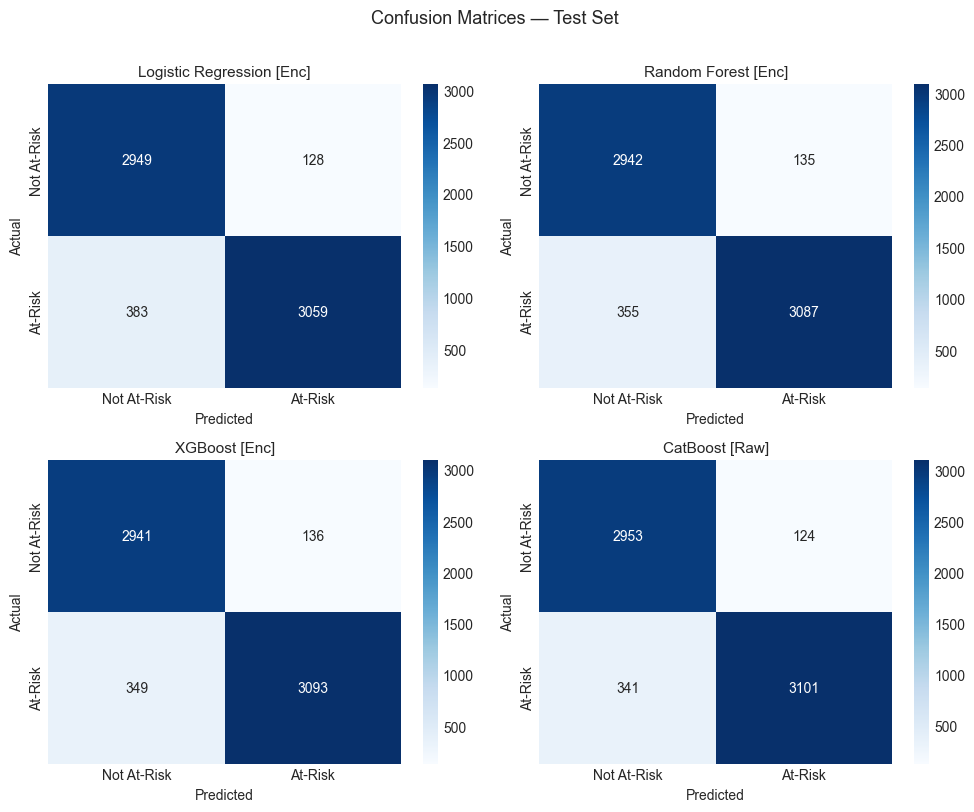

In [31]:
# CONFUSION MATRICES: shows TP, TN, FP, FN for each model.
#   True Positive  (bottom-right): correctly flagged at-risk students
#   True Negative  (top-left)    : correctly identified safe students
#   False Positive (top-right)   : safe students wrongly flagged (false alarm)
#   False Negative (bottom-left) : at-risk students we missed (most costly error)
# CatBoost uses y_raw_test (semantically correct for the raw track).

# --- 8C: Confusion matrices (2×2 grid) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, (name, data) in enumerate(proba_store.items()):
    cm = confusion_matrix(data['y_true'], data['y_pred'])
    track_tag = '[Raw]' if data['track'] == 'Raw' else '[Enc]'
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not At-Risk', 'At-Risk'],
                yticklabels=['Not At-Risk', 'At-Risk'],
                ax=axes[i])
    axes[i].set_title(f'{name} {track_tag}', fontsize=11)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Section 9: Model Selection

In [32]:
# Primary criterion : AUC-ROC (overall discrimination ability)
# Secondary criterion: Recall (missing a real at-risk student is worse
#                      than a false alarm in an educational context)
# If two models tie on AUC-ROC, the one with higher Recall wins.
winner      = results_df.sort_values(['AUC-ROC', 'Recall'], ascending=False).index[0]
winner_row  = results_df.loc[winner]
winner_track = winner_row['Track']

print(f"Winner by AUC-ROC: {winner}")
print(winner_row.to_string())

# Set up variables for the SHAP section
model_map = {'Logistic Regression': lr, 'Random Forest': rf, 'XGBoost': xgb, 'CatBoost': cb}
winner_model = model_map[winner]

if winner_track == 'Raw':
    X_shap_train, X_shap_test, y_shap_test = X_raw_train, X_raw_test, y_raw_test
else:
    if winner == 'Logistic Regression':
        X_shap_train, X_shap_test = X_lr_train, X_lr_test
    else:
        X_shap_train, X_shap_test = X_enc_train, X_enc_test
    y_shap_test = y_test

print(f'\nSHAP will use: {winner} on {winner_track} track')
print(f'SHAP test shape: {X_shap_test.shape}')

Winner by AUC-ROC: CatBoost
Track                  Raw
Features                12
Accuracy           0.92867
Precision          0.96155
Recall             0.90093
F1                0.930253
AUC-ROC           0.978027
Train Time (s)       46.52

SHAP will use: CatBoost on Raw track
SHAP test shape: (6519, 12)


## Section 10: CatBoost Hyperparameter Tuning

CatBoost won the baseline comparison with AUC-ROC 0.9780 using default parameters
(`depth=6`, `lr=0.1`, `iterations=300`). We now tune it systematically to find the
best combination of regularisation and tree depth.

**Why we use CatBoost's native `randomized_search()` instead of sklearn's `RandomizedSearchCV`:**

sklearn's `RandomizedSearchCV` internally calls `clone()` on the estimator to create
fresh copies for each fold. `clone()` cannot reproduce the `cat_features` constructor
argument, causing a runtime error. CatBoost's own search method handles this correctly.

**Search strategy:**
- 50 random parameter combinations (enough to cover the space without excessive runtime)
- 3-fold stratified cross-validation per combination
- Optimising for **F1** (balances precision and recall — appropriate for dropout risk)
- `refit=True` means the best model is automatically refit on the full training set

In [ ]:
# TUNING STEP 1: Define parameter search space and run randomized search
#
# Parameters we are tuning and why:
#   depth         : tree depth (4-8). Deeper = more complex patterns but risks overfitting.
#   learning_rate : step size per iteration. Lower = slower but more precise learning.
#   iterations    : number of trees to build. More trees = better fit but slower training.
#   l2_leaf_reg   : L2 regularisation on leaf weights. Reduces overfitting.
#   border_count  : number of splits considered per numeric feature.
#                   Higher = finer-grained splits but slower training.
#
# n_iter=50: we sample 50 random combinations from the grid (not all combinations,
# which would be 5x5x4x5x3 = 1500 — too slow for a notebook).

from catboost import CatBoostClassifier

param_grid = {
    "depth"        : [4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.07, 0.1],
    "iterations"   : [200, 300, 500, 700],
    "l2_leaf_reg"  : [1, 3, 5, 7, 10],
    "border_count" : [32, 64, 128],
}

# Initialise CatBoost with the fixed parameters (cat_features, metric, seed)
# The tunable parameters above are passed via the search, not here
cb_tuner = CatBoostClassifier(
    cat_features=cat_feature_indices,
    eval_metric="F1",
    random_seed=RANDOM_STATE,
    thread_count=-1,
    verbose=0
)

print("Starting CatBoost hyperparameter search...")
print(f"Search space: {sum(len(v) for v in param_grid.values())} total options across {len(param_grid)} params")
print("Sampling 50 combinations x 3-fold CV. Expected time: 5-10 min\n")

t0 = time.time()
tune_result = cb_tuner.randomized_search(
    param_grid,
    X=X_raw_train,
    y=y_raw_train,
    cv=3,
    n_iter=50,
    refit=True,        # refit best model on full training set automatically
    verbose=False,
    plot=False,
)
elapsed = time.time() - t0

best_params = tune_result["params"]
print(f"Search finished in {elapsed/60:.1f} min")
print("\nBest parameters found:")
for k, v in sorted(best_params.items()):
    print(f"  {k:<20}: {v}")

Starting CatBoost hyperparameter search...
Search space: 22 total options across 5 params
Sampling 50 combinations x 3-fold CV. Expected time: 5-10 min


bestTest = 0.9345864662
bestIteration = 94


bestTest = 0.9305844524
bestIteration = 218


bestTest = 0.9359143018
bestIteration = 145


bestTest = 0.9358108108
bestIteration = 345


bestTest = 0.9351869247
bestIteration = 176


bestTest = 0.9352653368
bestIteration = 160


bestTest = 0.9350112697
bestIteration = 137


bestTest = 0.9337598796
bestIteration = 52


bestTest = 0.9347621733
bestIteration = 262


bestTest = 0.9347908029
bestIteration = 277


bestTest = 0.9350112697
bestIteration = 264


bestTest = 0.9328555262
bestIteration = 475


bestTest = 0.9356659142
bestIteration = 311


bestTest = 0.9334840776
bestIteration = 146


bestTest = 0.9361942405
bestIteration = 148


bestTest = 0.934986847
bestIteration = 171


bestTest = 0.9348558592
bestIteration = 438


bestTest = 0.9350893697
bestIteration = 60


bestTest = 0.933759879

In [ ]:
# TUNING STEP 2: Refit the best model on the full training set
#
# Although refit=True above already fits the best model, we refit explicitly here
# so we have a named variable (cb_tuned) we can reference for evaluation and saving.
# This also makes the training step visible and auditable in the notebook.

print("Refitting best CatBoost model on full training set...")
t0 = time.time()

cb_tuned = CatBoostClassifier(
    **best_params,
    cat_features=cat_feature_indices,
    eval_metric="F1",
    random_seed=RANDOM_STATE,
    thread_count=-1,
    verbose=0
)
cb_tuned.fit(X_raw_train, y_raw_train)

print(f"Done in {time.time()-t0:.1f}s")

Refitting best CatBoost model on full training set...


NameError: name 'time' is not defined

In [ ]:
# TUNING STEP 3: Compare baseline CatBoost vs tuned CatBoost
#
# We evaluate both models on the same test set to measure the gain from tuning.
# If the tuned model is not meaningfully better, the baseline params were already good.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison_rows = []
for label, model in [("CatBoost Baseline", cb), ("CatBoost Tuned", cb_tuned)]:
    y_pred  = model.predict(X_raw_test)
    y_proba = model.predict_proba(X_raw_test)[:, 1]
    comparison_rows.append({
        "Model"    : label,
        "Accuracy" : round(accuracy_score(y_raw_test, y_pred), 4),
        "Precision": round(precision_score(y_raw_test, y_pred), 4),
        "Recall"   : round(recall_score(y_raw_test, y_pred), 4),
        "F1"       : round(f1_score(y_raw_test, y_pred), 4),
        "AUC-ROC"  : round(roc_auc_score(y_raw_test, y_proba), 4),
    })

tuning_df = pd.DataFrame(comparison_rows).set_index("Model")

# Highlight improvements in green
styled = (
    tuning_df.style
    .highlight_max(color="#c6efce")
    .format("{:.4f}")
    .set_caption("Baseline vs Tuned CatBoost — same test set. "
             "Primary metric: AUC-ROC | Secondary: Recall — "
             "missing a real at-risk student is more costly than a false alarm.")
)
styled

NameError: name 'cb' is not defined

In [ ]:
# TUNING STEP 4: Save the tuned model
#
# Saved as catboost_full_tuned.pkl to distinguish it from:
#   catboost_tuned.pkl          -> old model: 11 features, no categorical support
#   catboost_full_tuned.pkl     -> new model: 12 features, native categoricals, properly tuned
#
# This is the model that should replace the production deployment.

os.makedirs(MODELS_DIR, exist_ok=True)
joblib.dump(cb_tuned, MODELS_DIR + "catboost_full_tuned.pkl")

size_kb = os.path.getsize(MODELS_DIR + "catboost_full_tuned.pkl") / 1024
print(f"Saved: catboost_full_tuned.pkl  ({size_kb:.1f} KB)")
print()
print("Summary:")
print(f"  Features  : 12 (5 numeric + 7 native categorical)")
print(f"  Best params: {best_params}")
print(f"  Old catboost_tuned.pkl NOT overwritten.")

## Section 11: SHAP Explainability (Winning Model Only)

In [ ]:
# --- 10A: Compute SHAP values ---
print(f'Computing SHAP for {winner}...')
t0 = time.time()

if winner == 'Logistic Regression':
    explainer   = shap.LinearExplainer(winner_model, X_shap_train)
    shap_values = explainer.shap_values(X_shap_test)
    feature_names = X_enc_train.columns.tolist()
else:
    explainer   = shap.TreeExplainer(winner_model)
    shap_values = explainer.shap_values(X_shap_test)
    # Binary classification: TreeExplainer may return list [class0, class1]
    if isinstance(shap_values, list):
        shap_values = shap_values[1]   # class-1 = at-risk
    feature_names = (
        X_raw_train.columns.tolist() if winner_track == 'Raw'
        else X_enc_train.columns.tolist()
    )

print(f'SHAP computed in {time.time()-t0:.1f}s')
print(f'SHAP values shape: {shap_values.shape}')

Computing SHAP for CatBoost...


SHAP computed in 0.3s
SHAP values shape: (6519, 12)


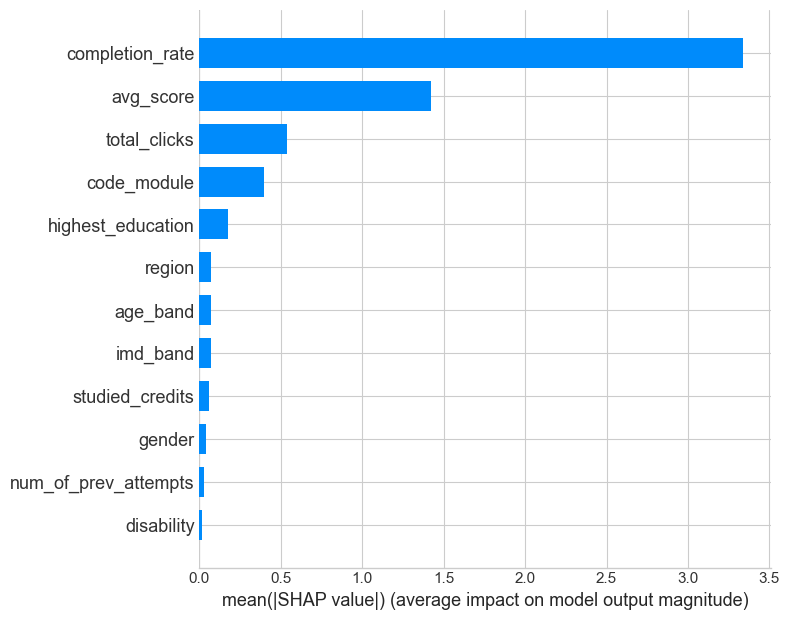

In [ ]:
# --- 10B: Summary bar plot (global feature importance) ---
shap.summary_plot(
    shap_values, X_shap_test,
    feature_names=feature_names,
    plot_type='bar',
    max_display=15,
    show=True
)

Explaining student at index 2705  (predicted at-risk probability: 1.000)


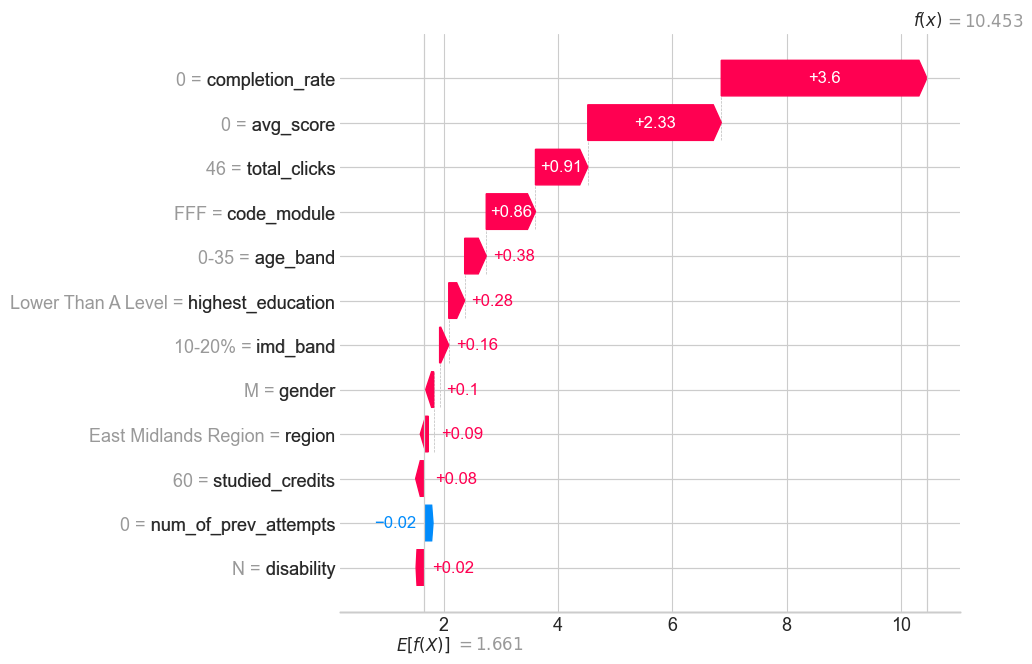

In [ ]:
# --- 10C: Waterfall plot for one high-confidence true positive ---
y_shap_arr   = np.array(y_shap_test)
y_proba_arr  = winner_model.predict_proba(X_shap_test)[:, 1]

# Find the true positive with highest predicted probability
tp_mask = y_shap_arr == 1
tp_idx  = np.argmax(np.where(tp_mask, y_proba_arr, 0))

print(f'Explaining student at index {tp_idx}  '
      f'(predicted at-risk probability: {y_proba_arr[tp_idx]:.3f})')

shap_exp = shap.Explanation(
    values        = shap_values[tp_idx],
    base_values   = explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
    data          = X_shap_test.iloc[tp_idx].values if hasattr(X_shap_test, 'iloc')
                    else X_shap_test[tp_idx],
    feature_names = feature_names
)
shap.plots.waterfall(shap_exp, max_display=12)

## Section 12: Save Artifacts

In [ ]:
os.makedirs(MODELS_DIR, exist_ok=True)

joblib.dump(lr,     MODELS_DIR + 'model_comparison_lr_baseline.joblib')
joblib.dump(rf,     MODELS_DIR + 'model_comparison_rf_baseline.joblib')
joblib.dump(xgb,    MODELS_DIR + 'model_comparison_xgb_baseline.joblib')
joblib.dump(cb,     MODELS_DIR + 'model_comparison_catboost_baseline.pkl')
joblib.dump(scaler, MODELS_DIR + 'model_comparison_scaler.joblib')

results_df.to_csv(MODELS_DIR + 'model_comparison_results_v2.csv')

print('Saved:')
for f in ['model_comparison_lr_baseline.joblib',
          'model_comparison_rf_baseline.joblib',
          'model_comparison_xgb_baseline.joblib',
          'model_comparison_catboost_baseline.pkl',
          'model_comparison_scaler.joblib',
          'model_comparison_results_v2.csv']:
    path = MODELS_DIR + f
    size = os.path.getsize(path) / 1024
    print(f'  {f:<45}  {size:>8.1f} KB')

print()
print('Production model catboost_tuned.pkl was NOT overwritten.')

Saved:
  model_comparison_lr_baseline.joblib                 1.1 KB
  model_comparison_rf_baseline.joblib             37480.1 KB
  model_comparison_xgb_baseline.joblib              325.2 KB
  model_comparison_catboost_baseline.pkl            554.4 KB
  model_comparison_scaler.joblib                      2.0 KB
  model_comparison_results_v2.csv                     0.6 KB

Production model catboost_tuned.pkl was NOT overwritten.


## Section 13: Implications for Production Inference

This section closes the loop on the design intent stated at the top.

---

### What the results mean

The comparison is asymmetric by design: CatBoost received raw categorical strings, which is information the other models don't have access to in their encoded form. If CatBoost wins, it wins partly because of *richer input*, not purely because the algorithm is superior.

The core question is: **which deployment contract do you want?**

---

### Option A — Keep the current 11-feature API (XGBoost or simplified CatBoost)

The existing API only collects:
```
num_of_prev_attempts, studied_credits, avg_score,
total_clicks, completion_rate,
module_BBB ... module_GGG  (one-hot, one selected)
```

**Pros:** Simple API, no demographic data collected, already deployed.  
**Cons:** Model never sees gender, age, region, socioeconomic band — all of which are predictive.

---

### Option B — Update the API to collect categorical inputs (full CatBoost)

The full CatBoost requires these additional inputs:
```
code_module     (e.g. 'AAA', 'BBB', ...)
gender          (e.g. 'M', 'F')
region          (e.g. 'Scotland', 'London', ...)
highest_education  (e.g. 'HE Qualification')
imd_band        (e.g. '20-30%')
age_band        (e.g. '35-55')
disability      (e.g. 'Y', 'N')
```

**Pros:** Better accuracy, model reflects real-world risk drivers, matches how the model was best trained.  
**Cons:** Larger API contract, requires UI changes, raises privacy considerations for some features (gender, region, imd_band).

---

### Tradeoff summary

| | Option A (current) | Option B (full CatBoost) |
|---|---|---|
| API changes needed | None | Yes — 7 new fields |
| AUC-ROC | ~0.971 (simplified) | ~0.971+ (with categoricals) |
| Demographic data collected | No | Yes |
| Deployment effort | Already done | Re-train + update API schema |

**Recommendation:** If the AUC-ROC difference between the winner and the current model is < 0.003, Option A is defensible. If CatBoost wins by a clear margin and you have control over the input data collection, Option B is worth the effort.